# Приклади роз'язання 
Візьмемо для простого прикладу простенький граф бамбук:

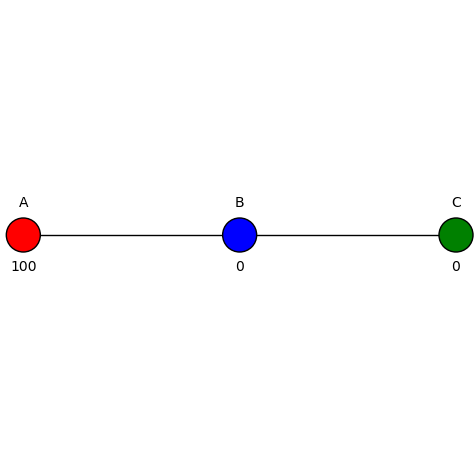

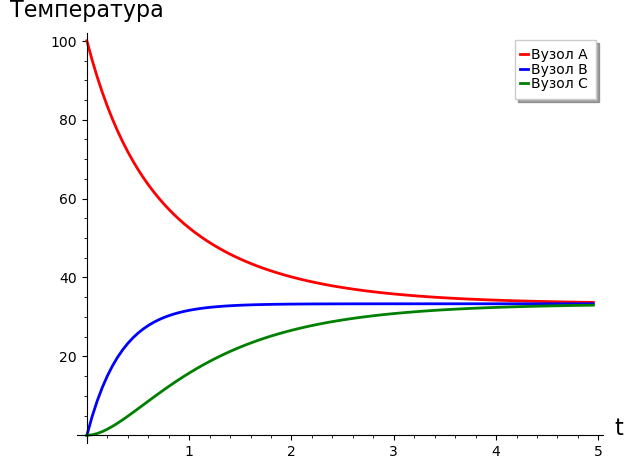

In [19]:
u0 = vector(QQ, [100, 0, 0])

G = graphs.PathGraph(3)
names = {0: "A", 1: "B", 2: "C"}
values = {0: f"{u0[0]}", 1: f"{u0[1]}", 2: f"{u0[2]}"}
labels = {i: f"{names[i]}\n\n\n\n{values[i]}" for i in range(3)}
colors = {
    'red': [0],
    'blue': [1],
    'green': [2]
}
show(G.plot(vertex_size=600, vertex_labels=labels, vertex_color=colors))

A = matrix(QQ, G.adjacency_matrix())

degrees = [G.degree(v) for v in G.vertices()]
D = diagonal_matrix(QQ, degrees)

L = D - A

Lambda, Q = L.diagonalization()

def u(t):
    exp_Lambda = diagonal_matrix([exp(-Lambda[i,i] * t) for i in range(Lambda.nrows())])
    return Q * exp_Lambda * Q.inverse() * u0

times = srange(0, 5, 0.05)

vals0 = []
vals1 = []
vals2 = []

for t in times:
    ut = u(t).n()
    vals0.append(ut[0])
    vals1.append(ut[1])
    vals2.append(ut[2])

p = line(list(zip(times, vals0)), color="red", legend_label="Вузол A", thickness=2)
p += line(list(zip(times, vals1)), color="blue", legend_label="Вузол B", thickness=2)
p += line(list(zip(times, vals2)), color="green", legend_label="Вузол C", thickness=2)

p.axes_labels(["t", "Температура"])
show(p)

Тут зображено те, як на графі змінюється температура за $5$ секунд, при початкових умовах де в нас дві вершини мають температуру $0$, та одна вершина нагріта аж до $100$.